# Finding Four-Top-Quark Events in LHC Collision Data

**Binary classification on real LHC simulation data, using tree ensembles and physics-engineered features


---
## 0. Setup

Data loading and feature engineering live in `src/` so the notebook stays focused on analysis. `src/parse.py` handles the raw file format; `src/features.py` builds the design matrix.


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

from src.parse import read_events, find_data_files, process_counts
from src.features import build_dataframe, feature_columns, FEATURE_GROUPS

RNG = 42
np.random.seed(RNG)

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})

SIG, BKG = "#c0392b", "#2c6fbb"
print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 3.0.3 | numpy 2.4.6


---
## 1. Loading the data

Each line of a raw file is one event, and lines have different lengths since events have different numbers of objects:

```
event ID; process; weight; MET; METphi; obj1,E,pt,eta,phi; obj2,E,pt,eta,phi; ...
```

Objects are jets (`j`), b-tagged jets (`b`), electrons/muons (`e-`/`e+`, `m-`/`m+`), and photons (`g`), each given as an energy-momentum four-vector `(E, pT, eta, phi)` — `pT` is momentum transverse to the beam, `eta`/`phi` are angular coordinates. Units are MeV in the raw files; `src/parse.py` converts to GeV.

**Data**: not committed to this repo (~100 MB across five per-process CSVs — see [`data/README.md`](../data/README.md)). Download them into `data/raw/` before running this notebook.


In [2]:
DATA_DIR = Path("../data/raw")
files = find_data_files(DATA_DIR)

if not files:
    raise FileNotFoundError(
        "No data files found under data/raw/. See data/README.md for download instructions."
    )

print(f"Found {len(files)} data file(s):")
for f in files:
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")


Found 5 data file(s):
  4top.csv  (59.3 MB)
  ttbarHiggs.csv  (13.2 MB)
  ttbarW.csv  (13.4 MB)
  ttbarWW.csv  (13.7 MB)
  ttbarZ.csv  (14.0 MB)


In [3]:
# Peek at one raw line before parsing anything.
with open(files[0]) as fh:
    raw_line = fh.readline().strip()

print("Raw line (truncated):")
print(" ", raw_line[:260], "...\n")

head = raw_line.split(";")
print(f"{'event ID':>14}: {head[0]}")
print(f"{'process ID':>14}: {head[1]}")
print(f"{'event weight':>14}: {head[2]}")
print(f"{'MET [MeV]':>14}: {head[3]}")
print(f"{'METphi':>14}: {head[4]}")
print(f"{'n objects':>14}: {len(head) - 5}")
print(f"\nFirst object: {head[5]}   ->  (type, E, pT, eta, phi)")

Raw line (truncated):
  70002;4top;2.9748e-08;234878;0.50707;b,288384,245272,-0.543959,-1.9042;j,392047,165199,1.50827,1.99874;j,248434,130323,-1.25273,-1.27606;j,161417,103983,-0.997634,-2.68032;j,190624,75629,1.57469,2.71146;j,92393.7,70754,0.707239,1.33859;b,220608,49055.4,2.18334 ...

      event ID: 70002
    process ID: 4top
  event weight: 2.9748e-08
     MET [MeV]: 234878
        METphi: 0.50707
     n objects: 11

First object: b,288384,245272,-0.543959,-1.9042   ->  (type, E, pT, eta, phi)


In [4]:
%%time
# Stream and parse. LIMIT caps events per file while iterating on features;
# set it to None for the full sample.
LIMIT = None

events = list(read_events(files, limit=LIMIT))
print(f"Parsed {len(events):,} events")

counts = process_counts(events)
print("\nProcesses present:")
for name, n in counts.items():
    print(f"  {name:<22} {n:>9,}  ({n / len(events):6.2%})")

Parsed 302,072 events

Processes present:
  4top                     152,000  (50.32%)
  ttbarW                    38,000  (12.58%)
  ttbarWW                   38,000  (12.58%)
  ttbarZ                    38,000  (12.58%)
  ttbarHiggs                36,072  (11.94%)
CPU times: user 3.81 s, sys: 145 ms, total: 3.96 s
Wall time: 4 s


The `process` column is generator-level truth — a luxury of simulated data. Real collision data carries no such label, which is why classifiers are trained on simulation and then applied to data; any mismatch between the two becomes a systematic uncertainty later. Worth keeping in mind before over-tuning.


In [5]:
# Everything that is not 4-top is background.
SIGNAL_PROCESSES = [p for p in counts if "4top" in p.lower() or "tttt" in p.lower()]
if not SIGNAL_PROCESSES:
    raise RuntimeError(f"No 4-top process found. Processes present: {list(counts)}")
print("Signal processes :", SIGNAL_PROCESSES)
print("Background       :", [p for p in counts if p not in SIGNAL_PROCESSES])

Signal processes : ['4top']
Background       : ['ttbarW', 'ttbarWW', 'ttbarZ', 'ttbarHiggs']


In [6]:
%%time
df = build_dataframe(events, signal_processes=SIGNAL_PROCESSES)
FEATURES = feature_columns(df)

print(f"Design matrix: {df.shape[0]:,} events x {len(FEATURES)} features")
print(f"Signal fraction (raw counts): {df.label.mean():.3%}")
df.head(3)

Design matrix: 302,072 events x 70 features
Signal fraction (raw counts): 50.319%
CPU times: user 11.7 s, sys: 399 ms, total: 12.1 s
Wall time: 12.3 s


,met,met_phi,n_jets_all,n_jets_light,n_bjets,n_leptons,n_photons,n_objects,b_fraction,ht,...,mt_lep1_met,dphi_lep1_met,dphi_jet1_met,sphericity,aplanarity,jet_eta_std,jet_eta_span,process,weight,label
0,234.878,0.50707,7,5,2,2,1,10,0.285714,840.2154,...,116.222655,0.795704,2.411270,0.268052,0.117766,1.278295,3.43607,4top,2.974800e-08,1
1,655.777,-1.61969,11,8,3,2,0,13,0.272727,1422.5158,...,7.743132,0.020840,3.019010,0.226828,0.033447,1.414813,4.46947,4top,2.974800e-08,1
2,198.895,1.08547,6,4,2,2,0,8,0.333333,968.0517,...,4.265207,0.031940,1.926354,0.112933,0.033519,1.194847,3.22018,4top,2.974800e-08,1


---
## 2. Exploratory analysis

### 2.1 Two kinds of imbalance

Two different numbers both look like "the class imbalance," and they disagree:

- **Raw counts** — how many rows of each class are in the file. An artifact of how much the dataset's authors chose to simulate.
- **Weighted counts** — every event carries a cross-section weight; the ratio of *summed weights* is what a real analysis would actually see.

Train on raw counts, evaluate on weighted yields — otherwise the evaluation answers the wrong question.


In [7]:
w_sig = df.loc[df.label == 1, "weight"].sum()
w_bkg = df.loc[df.label == 0, "weight"].sum()
n_sig, n_bkg = int((df.label == 1).sum()), int((df.label == 0).sum())

print(f"Raw counts       :  signal {n_sig:>8,}   background {n_bkg:>9,}   "
      f"-> signal is {n_sig / len(df):6.2%} of events")
print(f"Summed weights   :  signal {w_sig:>8.4g}   background {w_bkg:>9.4g}   "
      f"-> signal is {w_sig / (w_sig + w_bkg):6.4%} of nature")
print(f"\nWeighted imbalance is ~{(w_bkg / w_sig) / (n_bkg / n_sig):.0f}x more extreme "
      f"than the raw imbalance.")

Raw counts       :  signal  152,000   background   150,072   -> signal is 50.32% of events
Summed weights   :  signal    53.85   background     403.6   -> signal is 11.7727% of nature

Weighted imbalance is ~8x more extreme than the raw imbalance.


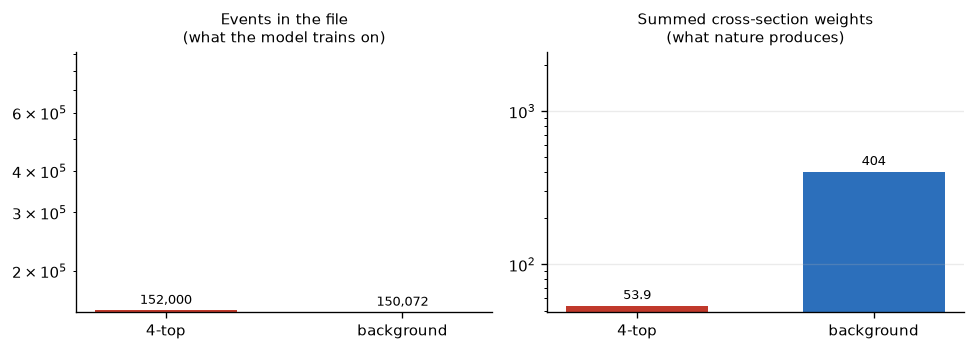

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.0))
for ax, (a, b, title, fmt) in zip(axes, [
    (n_sig, n_bkg, "Events in the file\n(what the model trains on)", "{:,.0f}"),
    (w_sig, w_bkg, "Summed cross-section weights\n(what nature produces)", "{:.3g}"),
]):
    bars = ax.bar(["4-top", "background"], [a, b], color=[SIG, BKG], width=0.6)
    ax.set_yscale("log")
    ax.set_title(title, fontsize=9)
    ax.bar_label(bars, fmt=fmt, fontsize=8, padding=2)
    ax.set_ylim(top=max(a, b) * 6)
    ax.grid(axis="x", visible=False)
fig.tight_layout()

### 2.2 What actually separates the two classes

Four top quarks means four `top -> W + b` decays; the background processes have two (plus a boson). Two straightforward predictions follow:

1. **More jets and b-jets** — up to 12 quarks from decays, vs. 6.
2. **More total hadronic energy (`HT`)** — four top quarks carry roughly 4x the rest mass into the event.

A third, textbook prediction is a same-sign lepton pair (four independent W decays make one common; `ttbar`'s two W's have opposite charge by construction, so a same-sign pair there requires a rare charge misreconstruction). It's the classic "four-top discovery channel" on an *inclusive* sample — but the next cell shows it doesn't apply here.


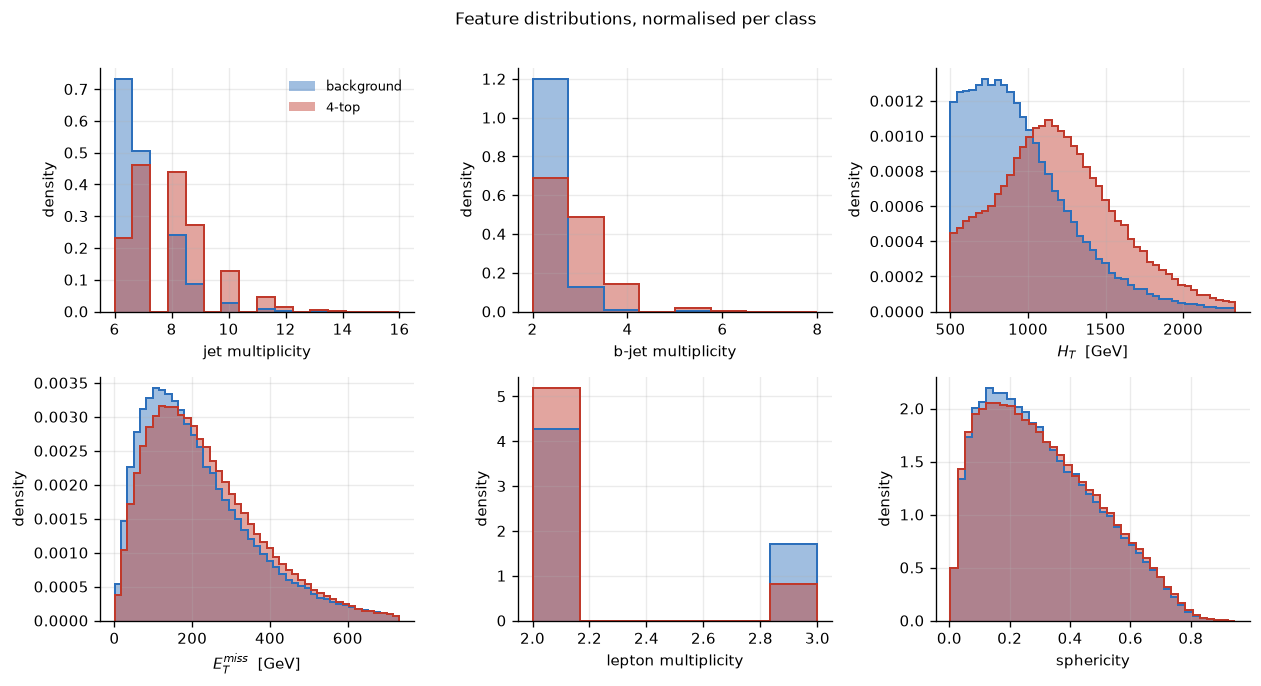

In [9]:
def compare(ax, col, bins=40, log=False, xlabel=None, clip=None):
    s = df.loc[df.label == 1, col].dropna()
    b = df.loc[df.label == 0, col].dropna()
    if clip is not None:
        hi = np.nanpercentile(pd.concat([s, b]), clip)
        s, b = s[s <= hi], b[b <= hi]
    rng = (min(s.min(), b.min()), max(s.max(), b.max()))
    kw = dict(bins=bins, range=rng, density=True, histtype="stepfilled", alpha=0.45)
    ax.hist(b, color=BKG, label="background", **kw)
    ax.hist(s, color=SIG, label="4-top", **kw)
    ax.hist(b, bins=bins, range=rng, density=True, histtype="step", color=BKG, lw=1.2)
    ax.hist(s, bins=bins, range=rng, density=True, histtype="step", color=SIG, lw=1.2)
    ax.set_xlabel(xlabel or col)
    ax.set_ylabel("density")
    if log:
        ax.set_yscale("log")

fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.6))
compare(axes[0, 0], "n_jets_all", bins=16, xlabel="jet multiplicity")
compare(axes[0, 1], "n_bjets", bins=8, xlabel="b-jet multiplicity")
compare(axes[0, 2], "ht", bins=45, clip=99, xlabel=r"$H_T$  [GeV]")
compare(axes[1, 0], "met", bins=45, clip=99, xlabel=r"$E_T^{miss}$  [GeV]")
compare(axes[1, 1], "n_leptons", bins=6, xlabel="lepton multiplicity")
compare(axes[1, 2], "sphericity", bins=40, xlabel="sphericity")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Feature distributions, normalised per class", y=1.01, fontsize=10)
fig.tight_layout()

In [10]:
print("n_leptons values present:", sorted(df.n_leptons.unique()))
print("has_same_sign_pair, per class:")
print(df.groupby("label")["has_same_sign_pair"].mean().rename({0: "background", 1: "4-top"}))


n_leptons values present: [np.int64(2), np.int64(3)]
has_same_sign_pair, per class:
label
background    1.0
4-top         1.0
Name: has_same_sign_pair, dtype: float64


Every event — signal and background alike — already has 2 or 3 leptons, and every one already has a same-sign pair. This isn't an inclusive collision sample: it's already been filtered to the same-sign/multi-lepton region, which is exactly the preselection a real four-top search applies first (precisely because that signature is so clean against *inclusive* `ttbar`).

Two things follow:

- **`has_same_sign_pair` is constant here → zero information for the classifier.** The cut was already made by the dataset, not by anything downstream.
- **The background actually present isn't inclusive `ttbar`.** It's the rarer, comparably-sized `ttbarW`/`ttbarZ`/`ttbarHiggs`/`ttbarWW` processes that survive the same cut for the same physical reason. Separating four-top from *those* is the real problem this notebook solves.

What's left to discriminate on: jet/b-jet multiplicity and `HT`, per predictions 1-2 above — confirmed later by permutation importance and the ablation study.

### 2.3 Correlation structure

Many features are built from the same underlying quantities and are correlated by construction. Trees don't mind this for prediction, but it splits importance between correlated features, which matters for interpretation later.


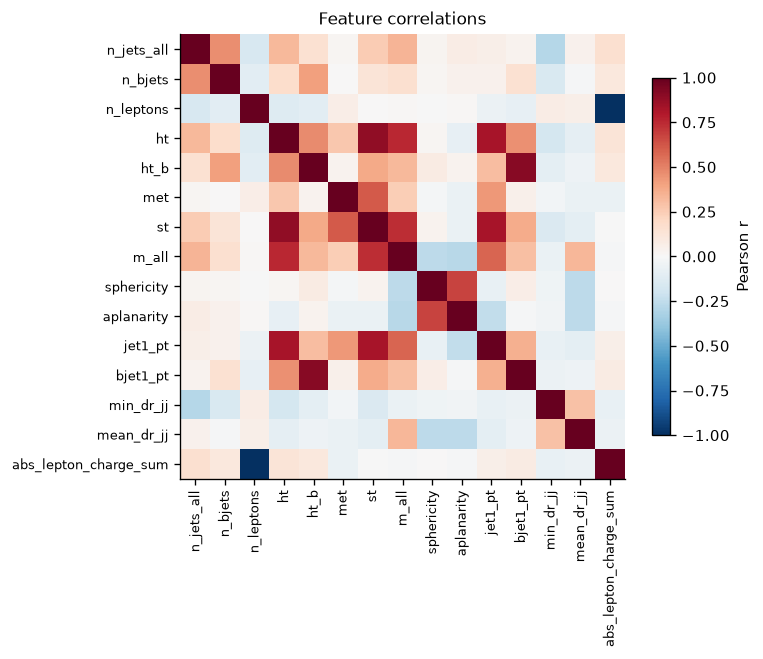

In [11]:
groups = ["n_jets_all", "n_bjets", "n_leptons", "ht", "ht_b", "met", "st",
          "m_all", "sphericity", "aplanarity", "jet1_pt", "bjet1_pt",
          "min_dr_jj", "mean_dr_jj", "abs_lepton_charge_sum"]
corr = df[groups].corr()

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(groups)), groups, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(groups)), groups, fontsize=7.5)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Feature correlations", fontsize=10)
fig.tight_layout()


---
## 3. Train / validation / test split

Three-way split: fit on **train**, tune hyperparameters and pick a threshold on **validation**, touch **test** exactly once at the end.

Stratified on the label — with an imbalanced target, an unstratified split can leave train and test with meaningfully different signal rates — and done before any threshold, hyperparameter, or scaling choice.


In [12]:
from sklearn.model_selection import train_test_split

X, y, w = df[FEATURES], df["label"].values, df["weight"].values

X_tr, X_tmp, y_tr, y_tmp, w_tr, w_tmp = train_test_split(
    X, y, w, test_size=0.30, stratify=y, random_state=RNG)
X_val, X_te, y_val, y_te, w_val, w_te = train_test_split(
    X_tmp, y_tmp, w_tmp, test_size=0.50, stratify=y_tmp, random_state=RNG)

for name, yy in [("train", y_tr), ("validation", y_val), ("test", y_te)]:
    print(f"{name:<11} {len(yy):>8,} events   signal {yy.mean():.3%}")

train        211,450 events   signal 50.319%
validation    45,311 events   signal 50.319%
test          45,311 events   signal 50.319%


---
## 4. Why accuracy is the wrong metric

The trivial classifier — always predict background — sets a floor that accuracy has to clear, and it's a floor close to 1 that says nothing about whether a model actually works.


In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

always_bkg = np.zeros_like(y_te)
print(f"'Always background' accuracy : {accuracy_score(y_te, always_bkg):.4f}")
print(f"'Always background' recall   : 0.0000  <- it finds zero signal events")
print(f"\nAny model scoring below {accuracy_score(y_te, always_bkg):.2%} accuracy is worse "
      f"than a constant.\nAny model scoring near it may be *identical* to a constant.")

'Always background' accuracy : 0.4968
'Always background' recall   : 0.0000  <- it finds zero signal events

Any model scoring below 49.68% accuracy is worse than a constant.
Any model scoring near it may be *identical* to a constant.


Three metrics replace it:

- **ROC AUC** — probability that a random signal event is ranked above a random background event. Threshold-free and insensitive to class balance — the right summary of *ranking quality*.
- **PR AUC (average precision)** — area under the precision-recall curve. Unlike ROC AUC, this *does* depend on class balance, which is the point: it reflects how hard it is to build a pure sample.
- **Expected significance (Z)** — the actual physics objective. How many standard deviations of signal stick out above background fluctuations, computed on *weighted* yields. Think of it as this field's analogue of choosing a business metric over a proxy metric: it's the number that determines whether a selection was actually worth deploying.

This notebook uses the Asimov form of Z, which stays well-behaved when background is small:

$$Z_A = \sqrt{2\left[(S+B)\ln\left(1+\frac{S}{B}\right) - S\right]}$$

with `S`, `B` the summed event weights passing a selection, scaled to a chosen luminosity.


In [14]:
def asimov_z(s, b, eps=1e-9):
    # Asimov discovery significance for expected yields s (signal), b (background).
    s, b = np.maximum(s, 0.0), np.maximum(b, eps)
    return np.sqrt(2.0 * ((s + b) * np.log1p(s / b) - s))


def yields(scores, y_true, weights, threshold, lumi=1.0):
    # Weighted signal and background yields passing scores >= threshold.
    sel = scores >= threshold
    s = weights[sel & (y_true == 1)].sum() * lumi
    b = weights[sel & (y_true == 0)].sum() * lumi
    return s, b


# Scale so the *inclusive* expected background yield is a round number. This
# sets the overall statistical scale; only the relative Z values are meaningful
# without the true luminosity and generator normalisation.
LUMI = 1e5 / w[y == 0].sum()
print(f"Inclusive expected yields at this scale:")
print(f"  signal     {w[y == 1].sum() * LUMI:>10,.0f}")
print(f"  background {w[y == 0].sum() * LUMI:>10,.0f}")
print(f"  Z (no selection) = {asimov_z(w[y == 1].sum() * LUMI, w[y == 0].sum() * LUMI):.2f}")

Inclusive expected yields at this scale:
  signal         13,344
  background    100,000
  Z (no selection) = 41.31


That's the benchmark to beat: with no selection at all, signal is buried. Every point of significance the classifier adds is the actual deliverable.


---
## 5. Baseline: raw kinematics only

The naive move: feed the model the momentum components of the leading few objects directly — the most direct "data → matrix" translation possible. It's also a trap: the discriminating information here is almost entirely in *how many* objects there are and *how much total energy* they carry, not in any single object's momentum.


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RAW = ["met", "met_phi",
       "jet1_pt", "jet1_eta", "jet1_E",
       "jet2_pt", "jet2_eta", "jet2_E",
       "lep1_pt", "lep1_eta", "lep1_E"]

results = {}


def evaluate(name, model, cols, note=""):
    # Fit on train, score on validation, record the standard metric set.
    m = model.fit(X_tr[cols].fillna(-999), y_tr)
    p = m.predict_proba(X_val[cols].fillna(-999))[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_val, p >= 0.5),
        "roc_auc": roc_auc_score(y_val, p),
        "pr_auc": average_precision_score(y_val, p),
        "n_features": len(cols),
        "note": note,
    }
    return m, p


tree_raw, p_tree_raw = evaluate(
    "Decision tree, raw kinematics",
    DecisionTreeClassifier(max_depth=6, random_state=RNG), RAW)
rf_raw, p_rf_raw = evaluate(
    "Random forest, raw kinematics",
    RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                           n_jobs=-1, random_state=RNG), RAW)

pd.DataFrame(results).T[["n_features", "accuracy", "roc_auc", "pr_auc"]]

,n_features,accuracy,roc_auc,pr_auc
"Decision tree, raw kinematics",11,0.628876,0.660647,0.628247
"Random forest, raw kinematics",11,0.631524,0.667444,0.64131


Accuracy is high, ROC AUC is mediocre — that gap is the whole lesson. The model learned to confidently say "background" and isn't really ranking anything. Reporting accuracy alone would make this look like a working classifier.

---
## 6. Physics-engineered features

Same models, same code — just swap in the 70-column feature set built from the physics reasoning in section 2.2.


In [16]:
tree_phys, p_tree_phys = evaluate(
    "Decision tree, physics features",
    DecisionTreeClassifier(max_depth=6, random_state=RNG), FEATURES)
rf_phys, p_rf_phys = evaluate(
    "Random forest, physics features",
    RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                           n_jobs=-1, random_state=RNG), FEATURES)

tbl = pd.DataFrame(results).T[["n_features", "accuracy", "roc_auc", "pr_auc"]]
tbl

,n_features,accuracy,roc_auc,pr_auc
"Decision tree, raw kinematics",11,0.628876,0.660647,0.628247
"Random forest, raw kinematics",11,0.631524,0.667444,0.64131
"Decision tree, physics features",70,0.733111,0.810456,0.807891
"Random forest, physics features",70,0.750943,0.828877,0.832713


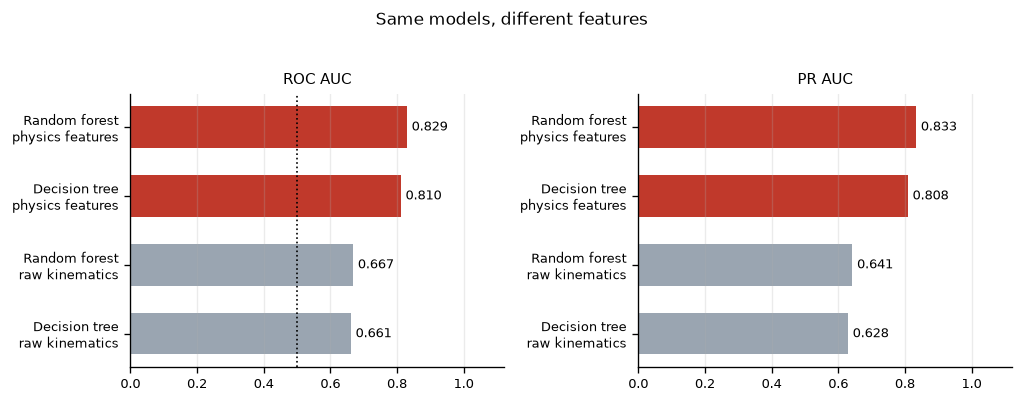

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.2))
labels = list(results)
short = [l.replace(", ", "\n") for l in labels]
colors = ["#9aa5b1", "#9aa5b1", SIG, SIG]

for ax, metric, title in zip(axes, ["roc_auc", "pr_auc"], ["ROC AUC", "PR AUC"]):
    vals = [results[l][metric] for l in labels]
    bars = ax.barh(short, vals, color=colors, height=0.6)
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=3)
    ax.set_xlim(0, 1.12)
    ax.set_title(title, fontsize=9)
    ax.grid(axis="y", visible=False)
    ax.tick_params(labelsize=7.5)
axes[0].axvline(0.5, color="k", ls=":", lw=1)
fig.suptitle("Same models, different features", y=1.03, fontsize=10)
fig.tight_layout()

---
## 7. Gradient boosting

Switching to `HistGradientBoostingClassifier`, for three reasons:

1. **Native NaN handling.** Missing values here are structural — an event with two b-jets simply has no third one, and that absence is informative. Filling with a sentinel like `-999` (as the baseline above did) forces the tree to waste splits rediscovering it; histogram boosting instead learns a default split direction for missing values.
2. **Fast enough to actually tune** on hundreds of thousands of events, via histogram binning.
3. It's the model class that gets deployed for this kind of tabular problem in practice.


In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.08, max_leaf_nodes=31,
    min_samples_leaf=40, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.15,
    random_state=RNG,
).fit(X_tr[FEATURES], y_tr)

p_hgb = hgb.predict_proba(X_val[FEATURES])[:, 1]
results["Gradient boosting, physics features"] = {
    "accuracy": accuracy_score(y_val, p_hgb >= 0.5),
    "roc_auc": roc_auc_score(y_val, p_hgb),
    "pr_auc": average_precision_score(y_val, p_hgb),
    "n_features": len(FEATURES),
    "note": "untuned",
}
print(f"stopped after {hgb.n_iter_} boosting iterations")
pd.DataFrame(results).T[["n_features", "accuracy", "roc_auc", "pr_auc"]]

stopped after 216 boosting iterations


,n_features,accuracy,roc_auc,pr_auc
"Decision tree, raw kinematics",11,0.628876,0.660647,0.628247
"Random forest, raw kinematics",11,0.631524,0.667444,0.64131
"Decision tree, physics features",70,0.733111,0.810456,0.807891
"Random forest, physics features",70,0.750943,0.828877,0.832713
"Gradient boosting, physics features",70,0.756262,0.835647,0.839991


### 7.1 Hyperparameter search

Random search over a grid: with 5 hyperparameters, a grid wastes most of its budget on the ones that don't matter, while random search samples every dimension at full resolution for the same cost. Scored on average precision (PR AUC) — the search should optimise the thing actually being reported.


In [19]:
%%time
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, randint

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(early_stopping=True, validation_fraction=0.15,
                                   random_state=RNG),
    param_distributions={
        "learning_rate": loguniform(0.02, 0.3),
        "max_leaf_nodes": randint(15, 96),
        "min_samples_leaf": randint(10, 200),
        "l2_regularization": loguniform(1e-3, 10.0),
        "max_iter": randint(200, 700),
    },
    n_iter=30,
    scoring="average_precision",
    cv=StratifiedKFold(3, shuffle=True, random_state=RNG),
    n_jobs=-1, random_state=RNG, refit=True, verbose=0,
).fit(X_tr[FEATURES], y_tr)

print(f"best CV average precision: {search.best_score_:.4f}\n")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:<20} {v if isinstance(v, int) else f'{v:.4g}'}")

best = search.best_estimator_
p_best = best.predict_proba(X_val[FEATURES])[:, 1]
results["Gradient boosting, tuned"] = {
    "accuracy": accuracy_score(y_val, p_best >= 0.5),
    "roc_auc": roc_auc_score(y_val, p_best),
    "pr_auc": average_precision_score(y_val, p_best),
    "n_features": len(FEATURES),
    "note": "randomised search, 30 draws",
}
pd.DataFrame(results).T[["n_features", "accuracy", "roc_auc", "pr_auc"]]

best CV average precision: 0.8395

  l2_regularization    0.06701
  learning_rate        0.03614
  max_iter             539
  max_leaf_nodes       44
  min_samples_leaf     199
CPU times: user 53.9 s, sys: 19 s, total: 1min 12s
Wall time: 2min 10s


,n_features,accuracy,roc_auc,pr_auc
"Decision tree, raw kinematics",11,0.628876,0.660647,0.628247
"Random forest, raw kinematics",11,0.631524,0.667444,0.64131
"Decision tree, physics features",70,0.733111,0.810456,0.807891
"Random forest, physics features",70,0.750943,0.828877,0.832713
"Gradient boosting, physics features",70,0.756262,0.835647,0.839991
"Gradient boosting, tuned",70,0.757653,0.83682,0.841114


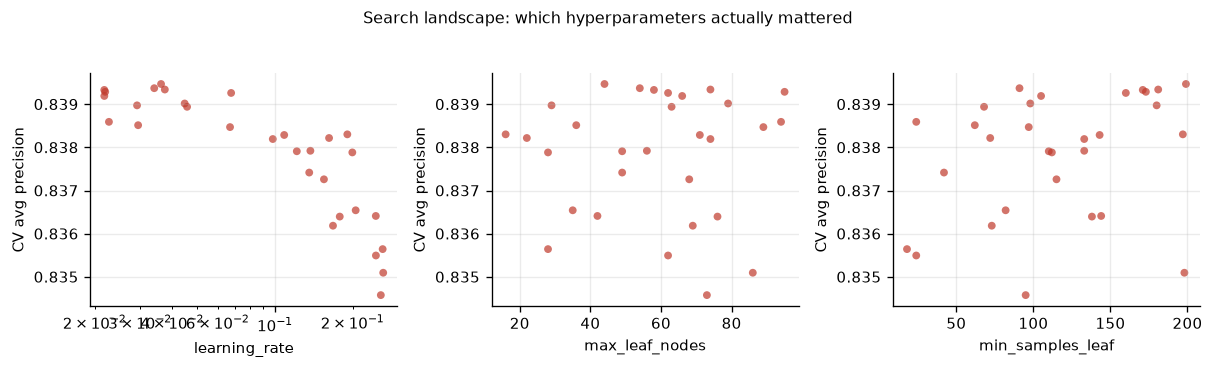

In [20]:
cv = pd.DataFrame(search.cv_results_)
fig, axes = plt.subplots(1, 3, figsize=(10.2, 2.9))
for ax, param in zip(axes, ["param_learning_rate", "param_max_leaf_nodes",
                            "param_min_samples_leaf"]):
    ax.scatter(cv[param].astype(float), cv["mean_test_score"],
               s=22, c=SIG, alpha=0.7, edgecolors="none")
    ax.set_xlabel(param.replace("param_", ""))
    ax.set_ylabel("CV avg precision")
    if param == "param_learning_rate":
        ax.set_xscale("log")
fig.suptitle("Search landscape: which hyperparameters actually mattered", y=1.04, fontsize=9.5)
fig.tight_layout()

---
## 8. Evaluation

The tuned model, evaluated once on the **test set**, which nothing so far has touched.


In [21]:
from sklearn.metrics import (roc_curve, precision_recall_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report, brier_score_loss)
from sklearn.calibration import calibration_curve

p_te = best.predict_proba(X_te[FEATURES])[:, 1]

print(f"Test ROC AUC : {roc_auc_score(y_te, p_te):.4f}")
print(f"Test PR AUC  : {average_precision_score(y_te, p_te):.4f}")
print(f"Brier score  : {brier_score_loss(y_te, p_te):.4f}  (lower is better)")

Test ROC AUC : 0.8361
Test PR AUC  : 0.8425
Brier score  : 0.1648  (lower is better)


Text(0.5, 1.0, 'Calibration')

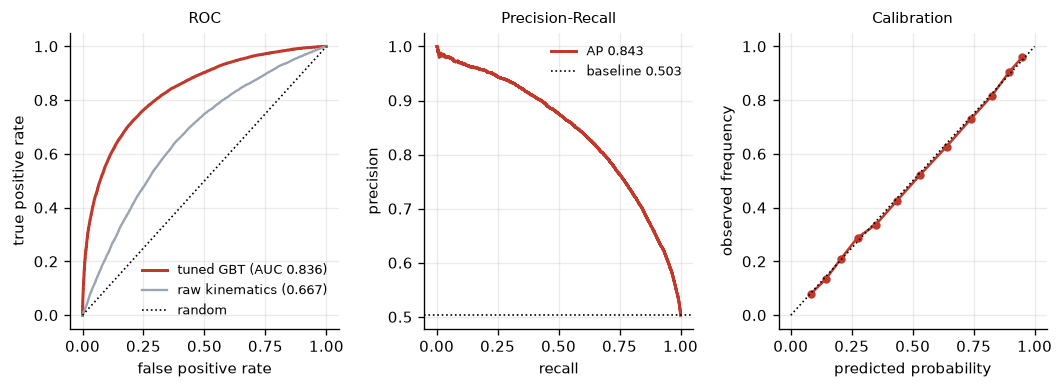

In [22]:
fig = plt.figure(figsize=(10.5, 3.2))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)

# ROC
ax = fig.add_subplot(gs[0])
fpr, tpr, _ = roc_curve(y_te, p_te)
ax.plot(fpr, tpr, color=SIG, lw=1.8,
        label=f"tuned GBT (AUC {roc_auc_score(y_te, p_te):.3f})")
fpr0, tpr0, _ = roc_curve(y_val, p_rf_raw)
ax.plot(fpr0, tpr0, color="#9aa5b1", lw=1.4, ls="-",
        label=f"raw kinematics ({roc_auc_score(y_val, p_rf_raw):.3f})")
ax.plot([0, 1], [0, 1], "k:", lw=1, label="random")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC", fontsize=9); ax.legend(frameon=False, fontsize=7.5, loc="lower right")

# PR
ax = fig.add_subplot(gs[1])
prec, rec, _ = precision_recall_curve(y_te, p_te)
ax.plot(rec, prec, color=SIG, lw=1.8,
        label=f"AP {average_precision_score(y_te, p_te):.3f}")
ax.axhline(y_te.mean(), color="k", ls=":", lw=1,
           label=f"baseline {y_te.mean():.3f}")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision-Recall", fontsize=9); ax.legend(frameon=False, fontsize=7.5)

# Calibration
ax = fig.add_subplot(gs[2])
frac, mean_pred = calibration_curve(y_te, p_te, n_bins=12, strategy="quantile")
ax.plot(mean_pred, frac, "o-", color=SIG, ms=4, lw=1.5)
ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Calibration", fontsize=9)

A well-calibrated score is interpretable — 0.8 should mean "about 80% of these are actually signal" — which is what lets a threshold be chosen on the real objective instead of by sweeping and hoping. (If the calibration curve is badly off the diagonal, wrap the model in `CalibratedClassifierCV` first.)

### 8.1 Choosing the threshold

The default 0.5 cutoff is arbitrary here. Instead: scan thresholds on validation, pick the one that maximises expected significance, apply it once to test.


In [23]:
thresholds = np.linspace(0.01, 0.995, 300)
z_val, s_val, b_val = [], [], []
for t in thresholds:
    s, b = yields(p_best, y_val, w_val, t, lumi=LUMI)
    z_val.append(asimov_z(s, b)); s_val.append(s); b_val.append(b)
z_val = np.array(z_val)

best_t = float(thresholds[np.nanargmax(z_val)])
print(f"Optimal threshold (validation): {best_t:.3f}")
print(f"Expected Z at that threshold  : {np.nanmax(z_val):.2f}")

Optimal threshold (validation): 0.843
Expected Z at that threshold  : 29.68


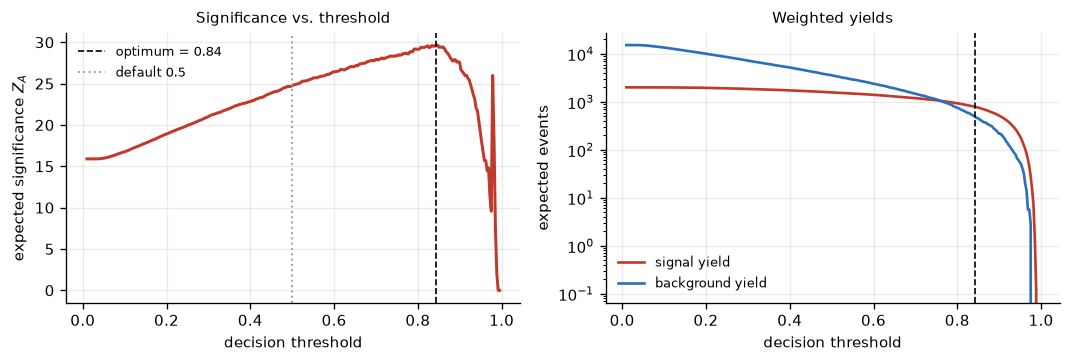

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.1))

ax = axes[0]
ax.plot(thresholds, z_val, color=SIG, lw=1.8)
ax.axvline(best_t, color="k", ls="--", lw=1, label=f"optimum = {best_t:.2f}")
ax.axvline(0.5, color="#9aa5b1", ls=":", lw=1.2, label="default 0.5")
ax.set_xlabel("decision threshold"); ax.set_ylabel(r"expected significance $Z_A$")
ax.set_title("Significance vs. threshold", fontsize=9)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
ax.plot(thresholds, s_val, color=SIG, lw=1.6, label="signal yield")
ax.plot(thresholds, b_val, color=BKG, lw=1.6, label="background yield")
ax.axvline(best_t, color="k", ls="--", lw=1)
ax.set_yscale("log"); ax.set_xlabel("decision threshold"); ax.set_ylabel("expected events")
ax.set_title("Weighted yields", fontsize=9)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

In [25]:
s_te, b_te = yields(p_te, y_te, w_te, best_t, lumi=LUMI)
s_all, b_all = w_te[y_te == 1].sum() * LUMI, w_te[y_te == 0].sum() * LUMI

print("TEST SET, at the threshold chosen on validation")
print("-" * 52)
print(f"{'':22} {'no selection':>13} {'selected':>13}")
print(f"{'signal yield':22} {s_all:>13,.1f} {s_te:>13,.1f}")
print(f"{'background yield':22} {b_all:>13,.1f} {b_te:>13,.1f}")
print(f"{'S/B':22} {s_all / b_all:>13.5f} {s_te / max(b_te, 1e-9):>13.5f}")
print(f"{'significance Z':22} {asimov_z(s_all, b_all):>13.2f} {asimov_z(s_te, b_te):>13.2f}")
print("-" * 52)
print(f"signal efficiency     {s_te / s_all:>13.2%}")
print(f"background rejection  {1 - b_te / b_all:>13.4%}")
print(f"\nsignificance gain     {asimov_z(s_te, b_te) / asimov_z(s_all, b_all):>13.1f}x")

TEST SET, at the threshold chosen on validation
----------------------------------------------------
                        no selection      selected
signal yield                 2,003.7         793.6
background yield            15,196.7         508.1
S/B                          0.13185       1.56188
significance Z                 15.92         29.36
----------------------------------------------------
signal efficiency            39.61%
background rejection       96.6563%

significance gain               1.8x


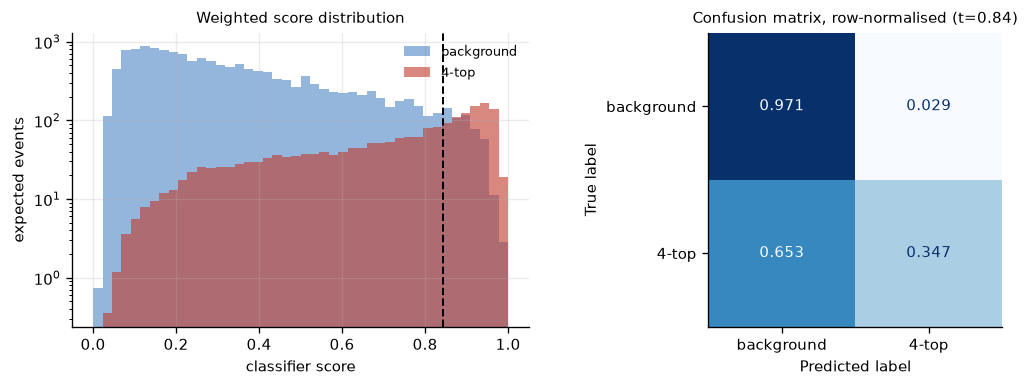

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3))

ax = axes[0]
bins = np.linspace(0, 1, 45)
ax.hist(p_te[y_te == 0], bins=bins, weights=w_te[y_te == 0] * LUMI,
        color=BKG, alpha=0.5, label="background")
ax.hist(p_te[y_te == 1], bins=bins, weights=w_te[y_te == 1] * LUMI,
        color=SIG, alpha=0.6, label="4-top")
ax.axvline(best_t, color="k", ls="--", lw=1.2)
ax.set_yscale("log"); ax.set_xlabel("classifier score")
ax.set_ylabel("expected events"); ax.set_title("Weighted score distribution", fontsize=9)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
cm = confusion_matrix(y_te, (p_te >= best_t).astype(int), normalize="true")
ConfusionMatrixDisplay(cm, display_labels=["background", "4-top"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format=".3f")
ax.set_title(f"Confusion matrix, row-normalised (t={best_t:.2f})", fontsize=9)
ax.grid(False)
fig.tight_layout()

In [27]:
print(classification_report(y_te, (p_te >= best_t).astype(int),
                            target_names=["background", "4-top"], digits=4))

              precision    recall  f1-score   support

  background     0.5947    0.9707    0.7375     22511
       4-top     0.9230    0.3468    0.5042     22800

    accuracy                         0.6568     45311
   macro avg     0.7588    0.6587    0.6208     45311
weighted avg     0.7599    0.6568    0.6201     45311



---
## 9. What did the model learn?

Permutation importance, not the built-in impurity importance — impurity importance is computed on training data and is biased toward high-cardinality continuous features (it will overrate `ht` and underrate `n_bjets`, simply because one has far more distinct values). Permutation importance instead measures the actual drop in held-out `average_precision` when a column is shuffled.


In [28]:
%%time
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best, X_te[FEATURES], y_te, scoring="average_precision",
    n_repeats=8, random_state=RNG, n_jobs=-1)

imp = (pd.DataFrame({"feature": FEATURES,
                     "importance": perm.importances_mean,
                     "std": perm.importances_std})
       .sort_values("importance", ascending=False)
       .reset_index(drop=True))
imp.head(18)

CPU times: user 3.43 s, sys: 853 ms, total: 4.28 s
Wall time: 1min 7s


,feature,importance,std
0,n_bjets,0.038894,0.001054
1,n_jets_all,0.020588,0.000982
2,jet1_mass,0.010247,0.000496
3,ht,0.009542,0.000314
4,jet1_pt,0.008256,0.000406
5,jet2_mass,0.006901,0.000266
6,bjet3_pt,0.005466,0.000494
7,bjet3_mass,0.004172,0.000444
8,jet2_pt,0.002107,0.000169
9,n_leptons,0.002057,0.000167


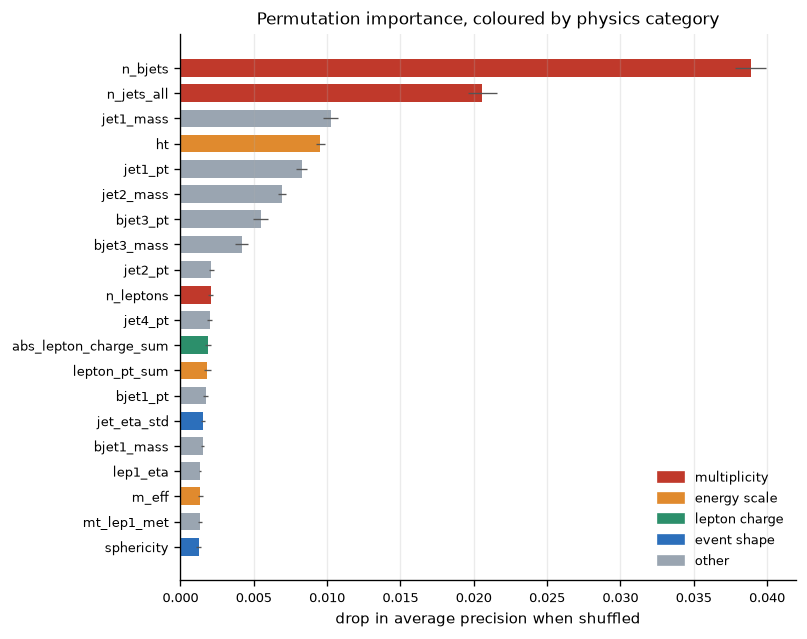

In [29]:
group_of = {f: g for g, feats in FEATURE_GROUPS.items() for f in feats}
palette = {"multiplicity": "#c0392b", "energy scale": "#e08a2e",
           "lepton charge": "#2c8f6b", "event shape": "#2c6fbb", "other": "#9aa5b1"}

top = imp.head(20).iloc[::-1]
cols = [palette[group_of.get(f, "other")] for f in top.feature]

fig, ax = plt.subplots(figsize=(6.8, 5.4))
ax.barh(top.feature, top.importance, xerr=top["std"],
        color=cols, height=0.7, error_kw=dict(lw=0.8, ecolor="#555"))
ax.set_xlabel("drop in average precision when shuffled")
ax.set_title("Permutation importance, coloured by physics category", fontsize=10)
ax.grid(axis="y", visible=False)
ax.tick_params(labelsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()

In [30]:
imp["group"] = imp.feature.map(lambda f: group_of.get(f, "other"))
by_group = (imp.groupby("group")["importance"]
            .agg(["sum", "mean", "count"])
            .sort_values("sum", ascending=False))
by_group.columns = ["total importance", "mean per feature", "n features"]
by_group

,total importance,mean per feature,n features
group,,,
multiplicity,0.062458,0.008923,7
other,0.053330,0.001270,42
energy scale,0.015890,0.001589,10
event shape,0.004435,0.000554,8
lepton charge,0.002066,0.000689,3


### 9.1 Optional: SHAP

Permutation importance says which features matter overall; SHAP explains individual predictions. Optional dependency, skipped cleanly if not installed.


In [37]:
try:
    import shap
    sub = X_te[FEATURES].sample(min(2000, len(X_te)), random_state=RNG)
    explainer = shap.TreeExplainer(best)
    sv = explainer.shap_values(sub)
    shap.summary_plot(sv, sub, max_display=18, show=True)
except ImportError:
    print("shap not installed - skipping.  `pip install shap` to enable this cell.")

shap not installed - skipping.  `pip install shap` to enable this cell.


---
## 10. Ablation: what is each feature family actually worth?

Permutation importance splits credit between correlated features, which understates whole families. A cleaner test: retrain from scratch with one family removed at a time and measure what's lost.


In [32]:
%%time
def score_subset(cols, label):
    m = HistGradientBoostingClassifier(
        **{k: v for k, v in search.best_params_.items()},
        early_stopping=True, validation_fraction=0.15, random_state=RNG,
    ).fit(X_tr[cols], y_tr)
    p = m.predict_proba(X_te[cols])[:, 1]
    s, b = yields(p, y_te, w_te, best_t, lumi=LUMI)
    return {"features": label, "n": len(cols),
            "roc_auc": roc_auc_score(y_te, p),
            "pr_auc": average_precision_score(y_te, p)}


rows = [score_subset(FEATURES, "all features"),
        score_subset(RAW, "raw kinematics only")]

for group, feats in FEATURE_GROUPS.items():
    keep = [f for f in FEATURES if f not in feats]
    rows.append(score_subset(keep, f"all minus '{group}'"))

for group, feats in FEATURE_GROUPS.items():
    keep = [f for f in FEATURES if f in feats]
    if keep:
        rows.append(score_subset(keep, f"only '{group}'"))

abl = pd.DataFrame(rows)
full = abl.loc[0, "pr_auc"]
abl["delta_pr_auc"] = abl.pr_auc - full
abl.sort_values("pr_auc", ascending=False).reset_index(drop=True)

CPU times: user 4min 51s, sys: 1min 41s, total: 6min 32s
Wall time: 42.3 s


,features,n,roc_auc,pr_auc,delta_pr_auc
0,all minus 'lepton charge',67,0.836246,0.842840,0.000308
1,all features,70,0.836091,0.842531,0.000000
2,all minus 'event shape',62,0.835683,0.842430,-0.000102
3,all minus 'energy scale',60,0.834447,0.841048,-0.001483
4,all minus 'multiplicity',63,0.831479,0.835813,-0.006718
5,only 'multiplicity',7,0.783459,0.780730,-0.061801
6,only 'energy scale',10,0.723997,0.708280,-0.134252
7,raw kinematics only,11,0.673150,0.654260,-0.188271
8,only 'event shape',8,0.646496,0.634210,-0.208322
9,only 'lepton charge',3,0.581918,0.550381,-0.292151


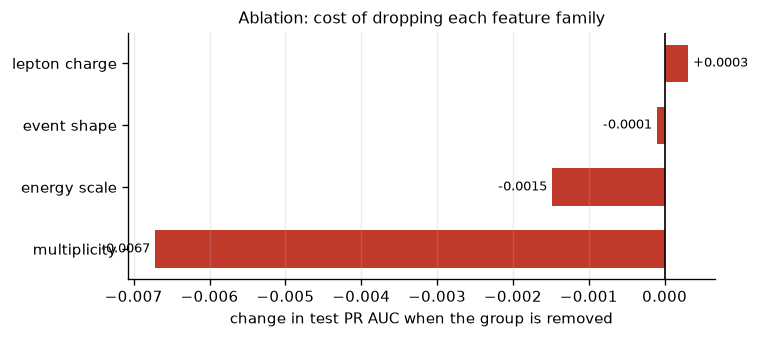

In [33]:
sub = abl[abl.features.str.startswith("all minus")].copy()
sub["group"] = sub.features.str.replace("all minus ", "").str.strip("'")
sub = sub.sort_values("delta_pr_auc")

fig, ax = plt.subplots(figsize=(6.4, 2.9))
bars = ax.barh(sub.group, sub.delta_pr_auc, color=SIG, height=0.6)
ax.bar_label(bars, fmt="%+.4f", fontsize=8, padding=3)
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("change in test PR AUC when the group is removed")
ax.set_title("Ablation: cost of dropping each feature family", fontsize=9.5)
ax.grid(axis="y", visible=False)
fig.tight_layout()

---
## 11. Summary


In [34]:
summary = pd.DataFrame(results).T[["n_features", "accuracy", "roc_auc", "pr_auc"]]
summary = summary.astype({"n_features": int}).round(4)
summary

,n_features,accuracy,roc_auc,pr_auc
"Decision tree, raw kinematics",11,0.628876,0.660647,0.628247
"Random forest, raw kinematics",11,0.631524,0.667444,0.64131
"Decision tree, physics features",70,0.733111,0.810456,0.807891
"Random forest, physics features",70,0.750943,0.828877,0.832713
"Gradient boosting, physics features",70,0.756262,0.835647,0.839991
"Gradient boosting, tuned",70,0.757653,0.83682,0.841114


In [35]:
print("FINAL MODEL - test set")
print("=" * 56)
print(f"{'model':<26} tuned HistGradientBoosting")
print(f"{'features':<26} {len(FEATURES)}")
print(f"{'threshold':<26} {best_t:.3f}  (chosen on validation, by max Z)")
print(f"{'ROC AUC':<26} {roc_auc_score(y_te, p_te):.4f}")
print(f"{'PR AUC':<26} {average_precision_score(y_te, p_te):.4f}")
print(f"{'signal efficiency':<26} {s_te / s_all:.2%}")
print(f"{'background rejection':<26} {1 - b_te / b_all:.4%}")
print(f"{'S/B improvement':<26} {(s_te / max(b_te, 1e-9)) / (s_all / b_all):.1f}x")
print(f"{'significance gain':<26} {asimov_z(s_te, b_te) / asimov_z(s_all, b_all):.1f}x")
print("=" * 56)


FINAL MODEL - test set
model                      tuned HistGradientBoosting
features                   70
threshold                  0.843  (chosen on validation, by max Z)
ROC AUC                    0.8361
PR AUC                     0.8425
signal efficiency          39.61%
background rejection       96.6563%
S/B improvement            11.8x
significance gain          1.8x
